# Titanic Dataset - EDA and Preprocessing

This notebook performs exploratory data analysis and preprocessing on the Titanic dataset.

## Objectives:
1. Load and explore the raw dataset
2. Analyze missing values and data distributions
3. Perform feature engineering
4. Handle missing values
5. Encode categorical variables
6. Save processed dataset

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [3]:
# Load the dataset
data_path = Path('../data/raw/Titanic-Dataset.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nNumber of samples: {len(df)}")
print(f"Number of features: {df.shape[1]}")

Dataset shape: (891, 12)

Number of samples: 891
Number of features: 12


## 2. Initial Data Exploration

In [4]:
# Display first few rows
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Statistical summary for categorical variables
df.describe(include=['object'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


## 3. Missing Values Analysis

In [8]:
# Calculate missing values
missing_data = pd.DataFrame({
    'Total': df.isnull().sum(),
    'Percent': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Total'] > 0].sort_values('Total', ascending=False)
print("Missing Values:")
print(missing_data)

Missing Values:
          Total    Percent
Cabin       687  77.104377
Age         177  19.865320
Embarked      2   0.224467


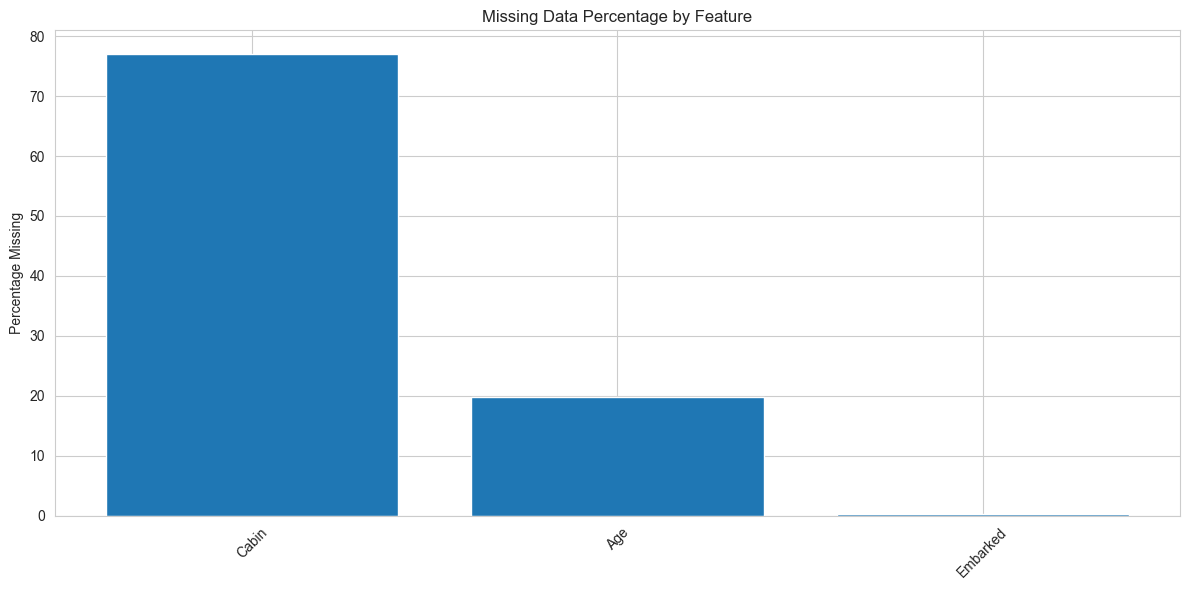

In [9]:
# Visualize missing values
plt.figure(figsize=(12, 6))
missing_cols = missing_data.index
if len(missing_cols) > 0:
    plt.bar(range(len(missing_cols)), missing_data['Percent'])
    plt.xticks(range(len(missing_cols)), missing_cols, rotation=45)
    plt.ylabel('Percentage Missing')
    plt.title('Missing Data Percentage by Feature')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

## 4. Target Variable Analysis

In [10]:
# Survival rate
survival_rate = df['Survived'].value_counts()
print("Survival Distribution:")
print(survival_rate)
print(f"\nSurvival Rate: {(survival_rate[1] / len(df)) * 100:.2f}%")

Survival Distribution:
0    549
1    342
Name: Survived, dtype: int64

Survival Rate: 38.38%


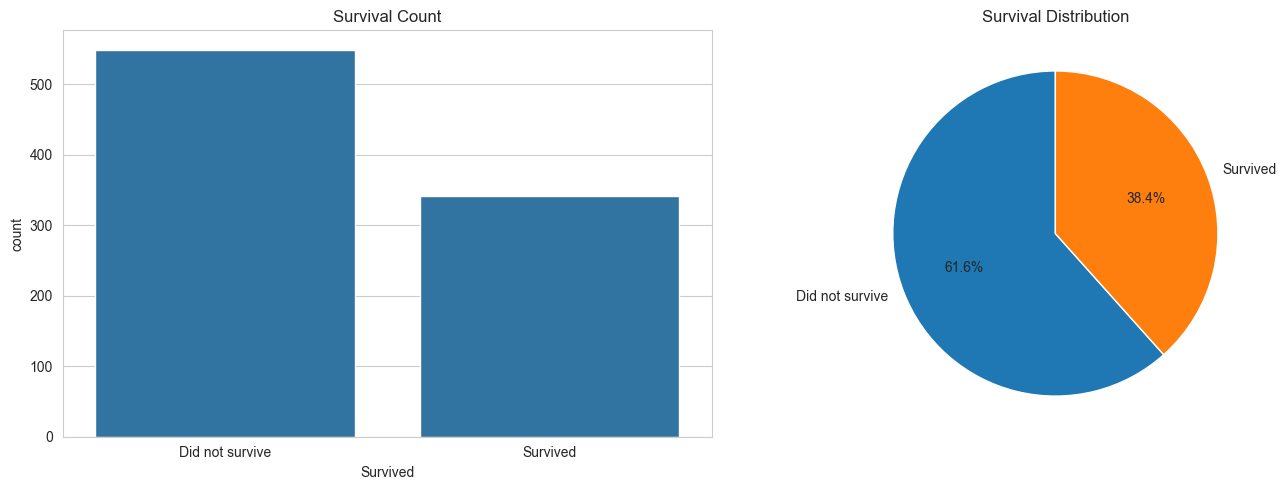

In [11]:
# Visualize survival distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='Survived', ax=axes[0])
axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Did not survive', 'Survived'])

# Pie chart
axes[1].pie(survival_rate.values, labels=['Did not survive', 'Survived'], 
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Survival Distribution')

plt.tight_layout()
plt.show()

## 5. Feature Analysis

### 5.1 Passenger Class (Pclass)

Passenger Class Distribution:
1    216
2    184
3    491
Name: Pclass, dtype: int64


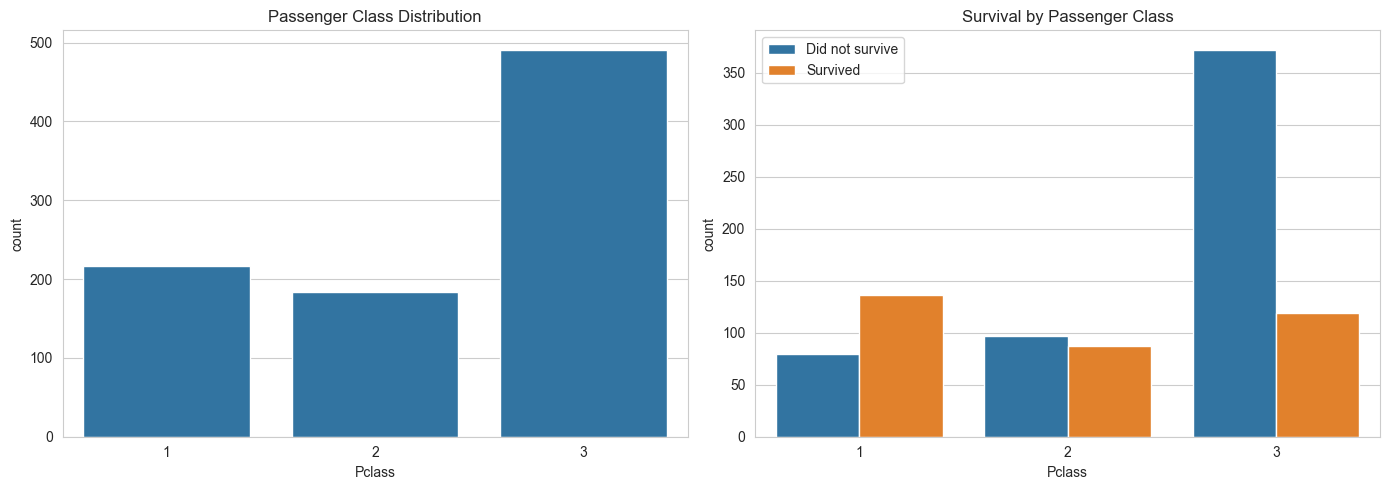


Survival Rate by Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [12]:
# Pclass distribution
print("Passenger Class Distribution:")
print(df['Pclass'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
sns.countplot(data=df, x='Pclass', ax=axes[0])
axes[0].set_title('Passenger Class Distribution')

# Survival by class
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[1])
axes[1].set_title('Survival by Passenger Class')
axes[1].legend(['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()

# Survival rate by class
print("\nSurvival Rate by Class:")
print(df.groupby('Pclass')['Survived'].mean())

### 5.2 Sex

Sex Distribution:
male      577
female    314
Name: Sex, dtype: int64


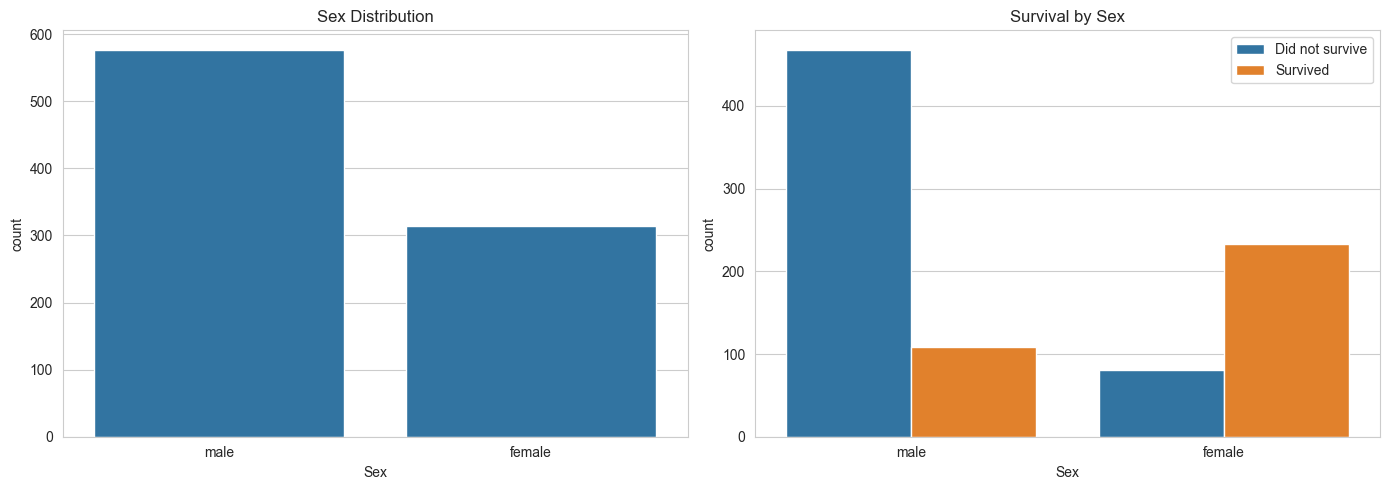


Survival Rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [13]:
# Sex distribution
print("Sex Distribution:")
print(df['Sex'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
sns.countplot(data=df, x='Sex', ax=axes[0])
axes[0].set_title('Sex Distribution')

# Survival by sex
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[1])
axes[1].set_title('Survival by Sex')
axes[1].legend(['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()

# Survival rate by sex
print("\nSurvival Rate by Sex:")
print(df.groupby('Sex')['Survived'].mean())

### 5.3 Age

Age Statistics:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


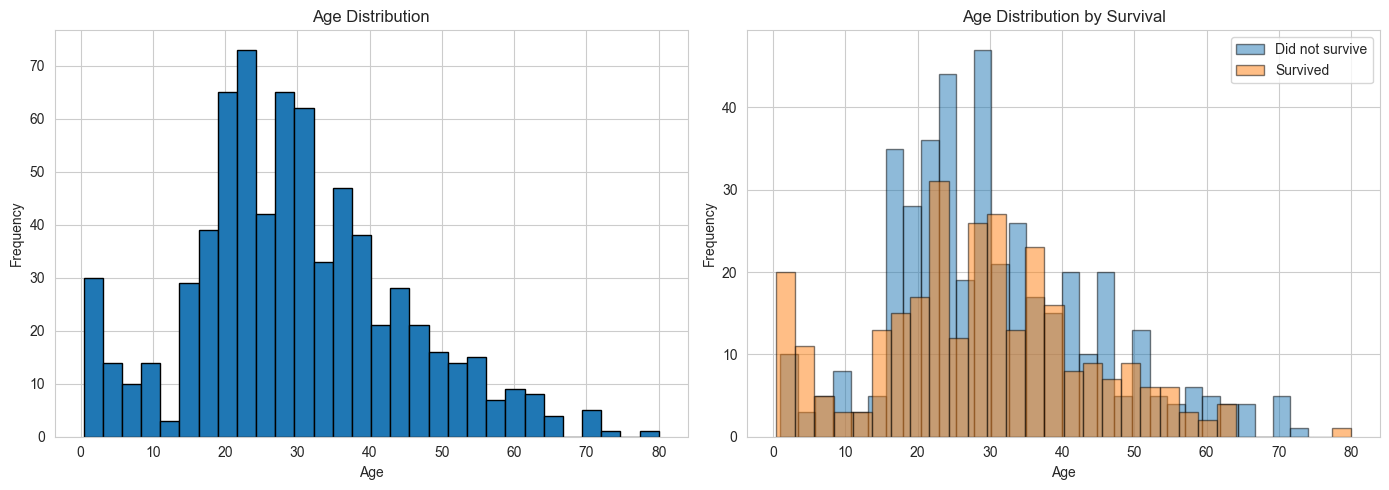

In [14]:
# Age distribution
print("Age Statistics:")
print(df['Age'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
df['Age'].hist(bins=30, ax=axes[0], edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# Age distribution by survival
df[df['Survived'] == 0]['Age'].hist(bins=30, alpha=0.5, label='Did not survive', ax=axes[1], edgecolor='black')
df[df['Survived'] == 1]['Age'].hist(bins=30, alpha=0.5, label='Survived', ax=axes[1], edgecolor='black')
axes[1].set_title('Age Distribution by Survival')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.4 SibSp and Parch (Family Size)

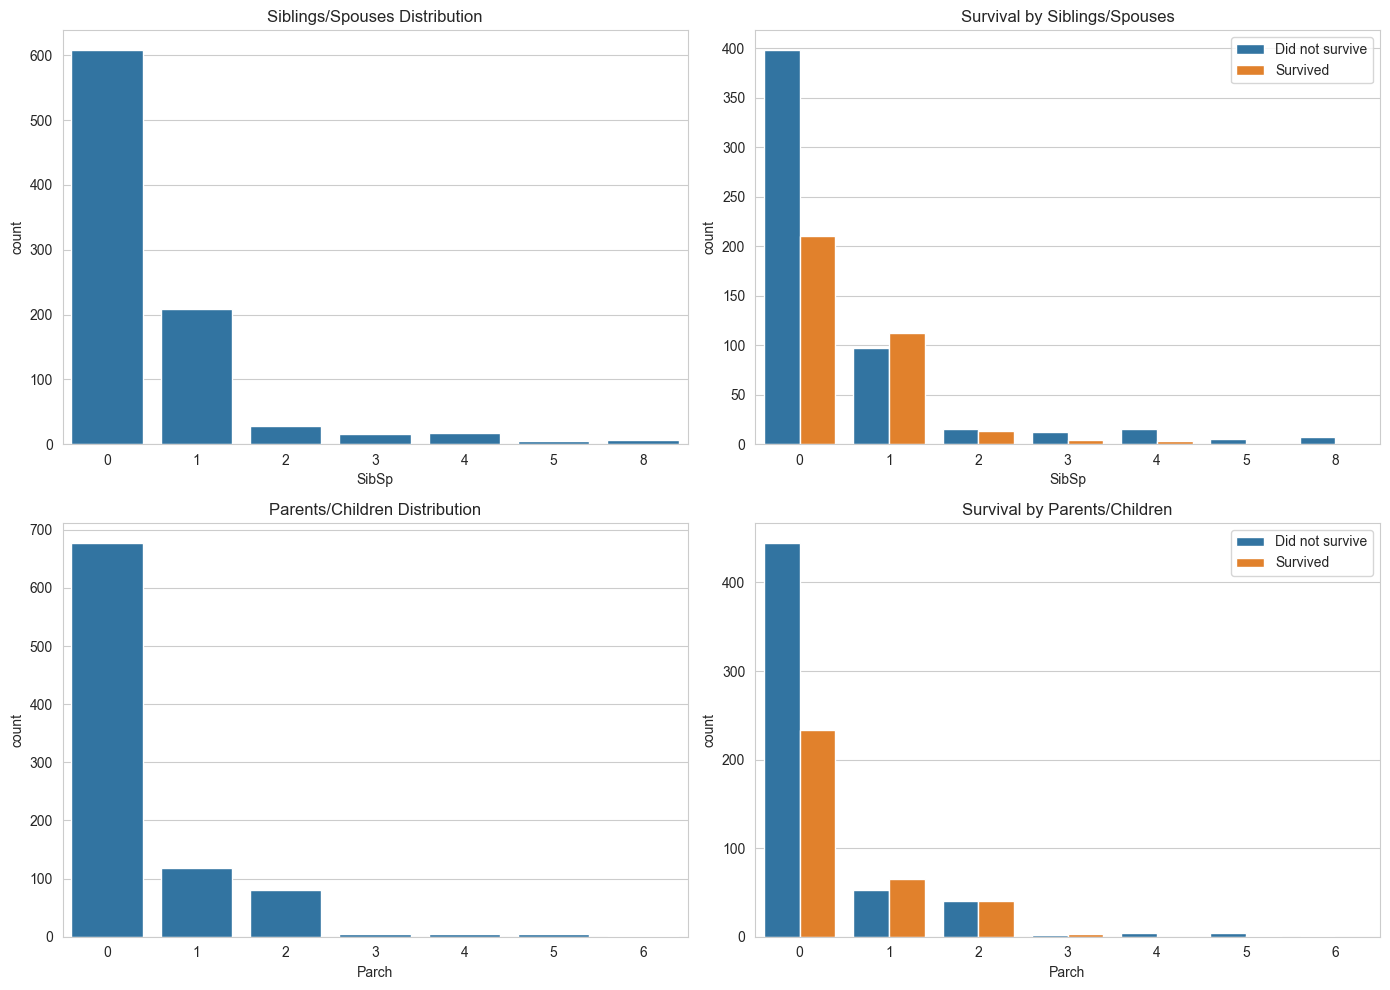

In [15]:
# SibSp and Parch distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SibSp
sns.countplot(data=df, x='SibSp', ax=axes[0, 0])
axes[0, 0].set_title('Siblings/Spouses Distribution')

sns.countplot(data=df, x='SibSp', hue='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival by Siblings/Spouses')
axes[0, 1].legend(['Did not survive', 'Survived'])

# Parch
sns.countplot(data=df, x='Parch', ax=axes[1, 0])
axes[1, 0].set_title('Parents/Children Distribution')

sns.countplot(data=df, x='Parch', hue='Survived', ax=axes[1, 1])
axes[1, 1].set_title('Survival by Parents/Children')
axes[1, 1].legend(['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()

### 5.5 Fare

Fare Statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


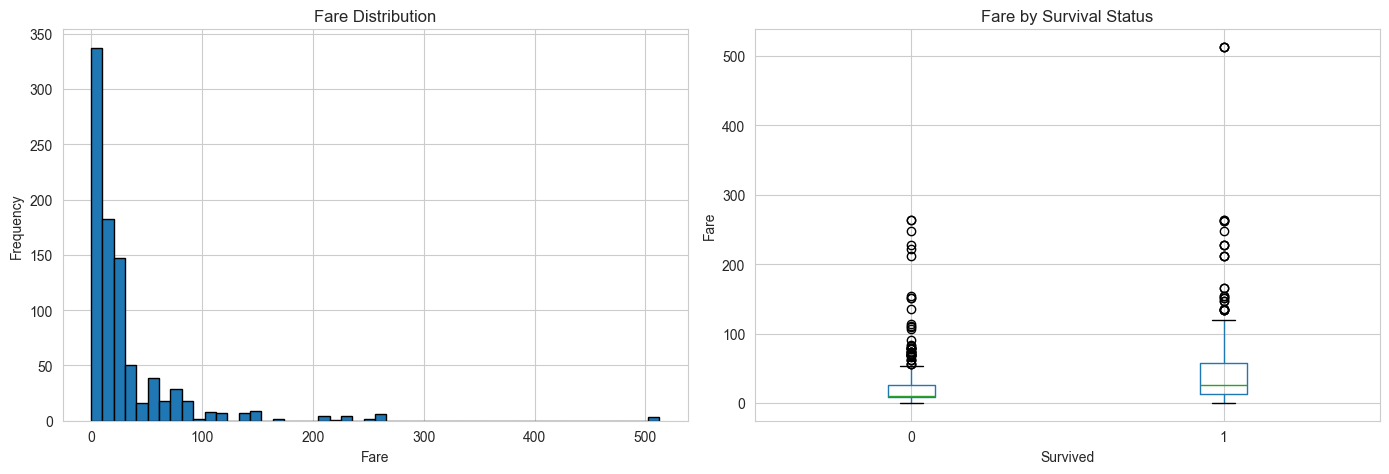

In [16]:
# Fare statistics
print("Fare Statistics:")
print(df['Fare'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fare distribution (log scale due to skewness)
df['Fare'].hist(bins=50, ax=axes[0], edgecolor='black')
axes[0].set_title('Fare Distribution')
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Frequency')

# Fare by survival
df.boxplot(column='Fare', by='Survived', ax=axes[1])
axes[1].set_title('Fare by Survival Status')
axes[1].set_xlabel('Survived')
axes[1].set_ylabel('Fare')
plt.suptitle('')

plt.tight_layout()
plt.show()

### 5.6 Embarked

Embarkation Port Distribution:
S    644
C    168
Q     77
Name: Embarked, dtype: int64


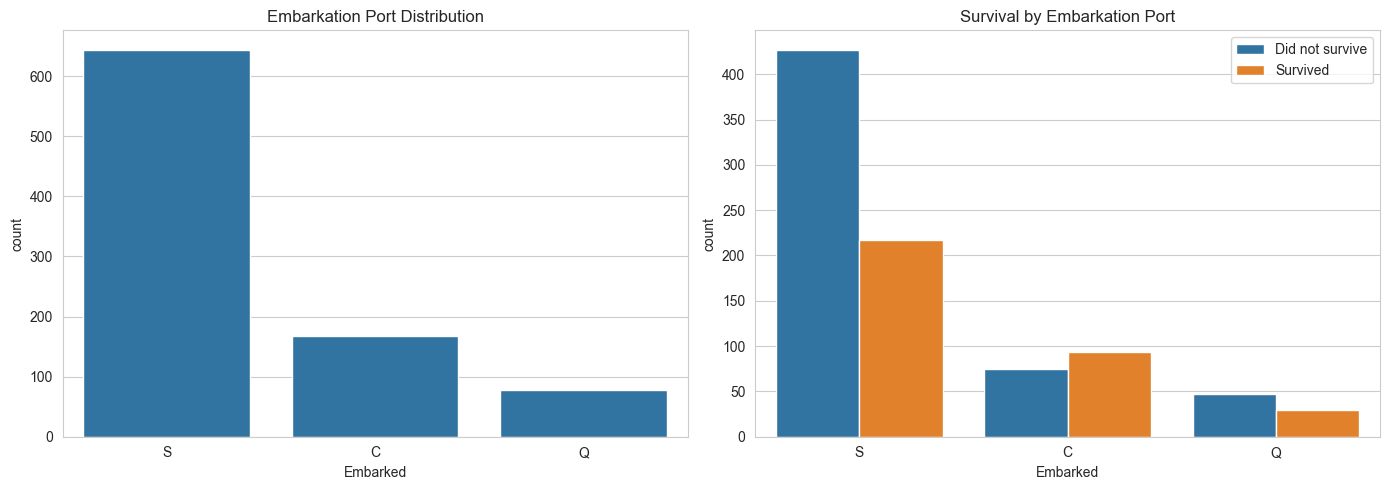


Survival Rate by Embarkation Port:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [17]:
# Embarked distribution
print("Embarkation Port Distribution:")
print(df['Embarked'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
sns.countplot(data=df, x='Embarked', ax=axes[0])
axes[0].set_title('Embarkation Port Distribution')

# Survival by embarked
sns.countplot(data=df, x='Embarked', hue='Survived', ax=axes[1])
axes[1].set_title('Survival by Embarkation Port')
axes[1].legend(['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()

print("\nSurvival Rate by Embarkation Port:")
print(df.groupby('Embarked')['Survived'].mean())

### 5.7 Correlation Analysis

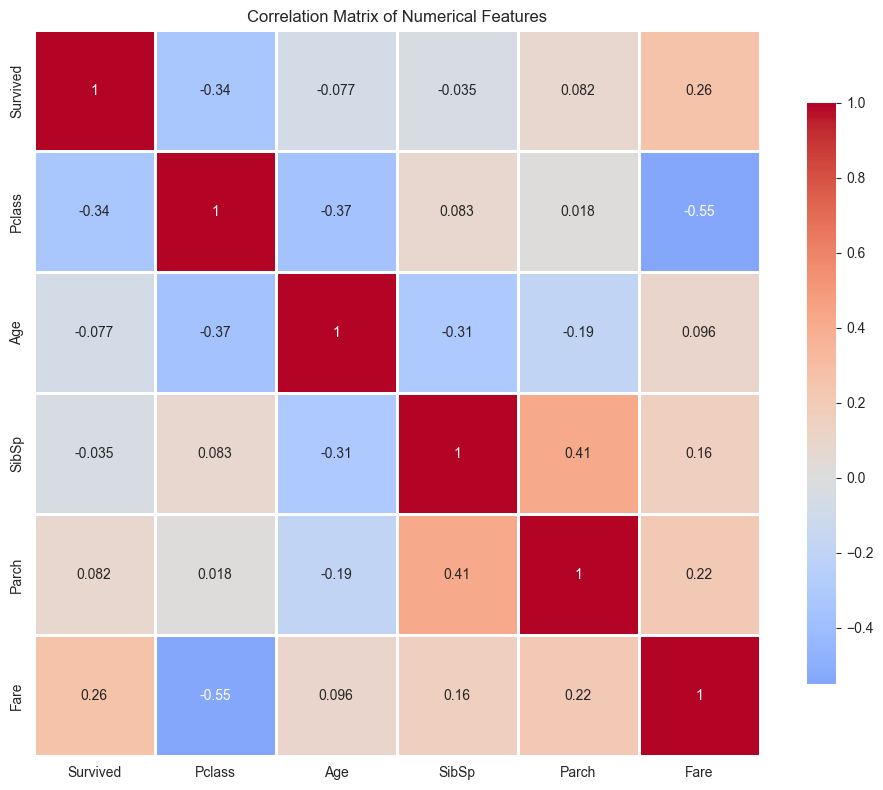


Correlation with Survival:
Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077221
Pclass     -0.338481
Name: Survived, dtype: float64


In [18]:
# Select numerical features for correlation
numerical_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
correlation_matrix = df[numerical_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

print("\nCorrelation with Survival:")
print(correlation_matrix['Survived'].sort_values(ascending=False))

## 6. Feature Engineering

In [19]:
# Create a copy for preprocessing
df_processed = df.copy()

### 6.1 Family Size Feature

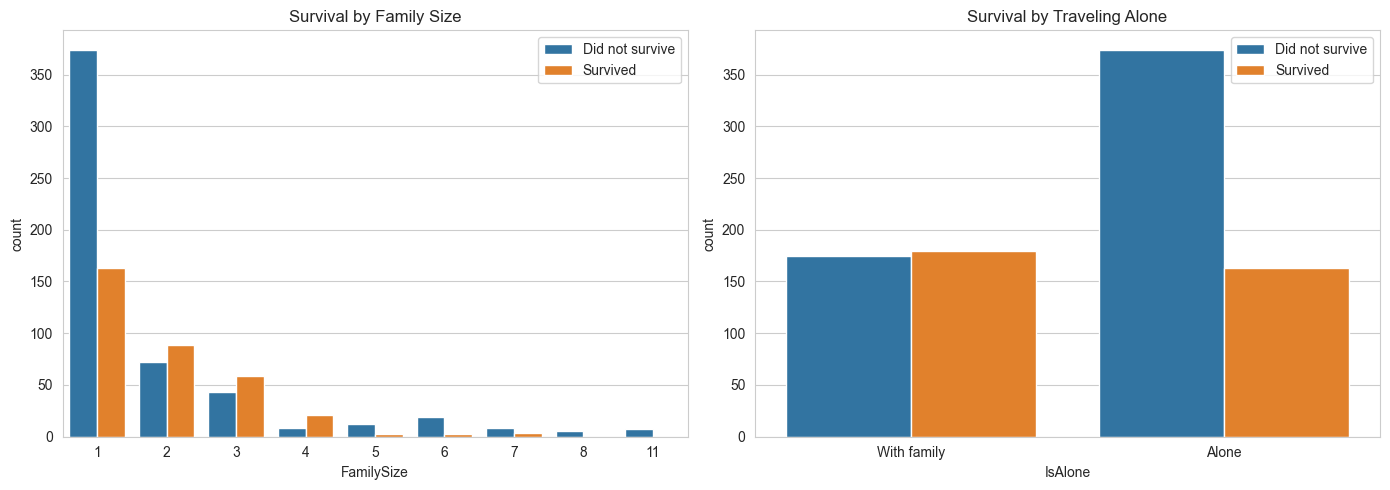

Survival Rate by Family Size:
FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

Survival Rate - Alone vs With Family:
IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


In [20]:
# Create FamilySize feature (SibSp + Parch + 1 for the person themselves)
df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1

# Create IsAlone feature
df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_processed, x='FamilySize', hue='Survived', ax=axes[0])
axes[0].set_title('Survival by Family Size')
axes[0].legend(['Did not survive', 'Survived'])

sns.countplot(data=df_processed, x='IsAlone', hue='Survived', ax=axes[1])
axes[1].set_title('Survival by Traveling Alone')
axes[1].set_xticklabels(['With family', 'Alone'])
axes[1].legend(['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()

print("Survival Rate by Family Size:")
print(df_processed.groupby('FamilySize')['Survived'].mean())
print("\nSurvival Rate - Alone vs With Family:")
print(df_processed.groupby('IsAlone')['Survived'].mean())

### 6.2 Title Extraction from Name

Title Distribution:
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: Title, dtype: int64

Title Distribution after Mapping:
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: Title, dtype: int64


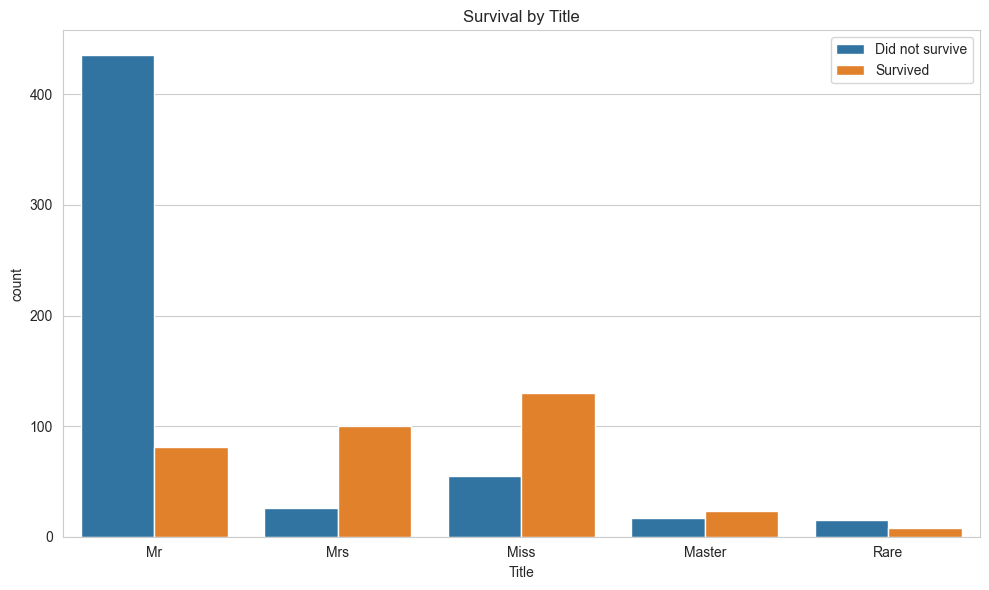


Survival Rate by Title:
Title
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Rare      0.347826
Name: Survived, dtype: float64


In [21]:
# Extract title from name
df_processed['Title'] = df_processed['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Check title distribution
print("Title Distribution:")
print(df_processed['Title'].value_counts())

# Group rare titles
title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Mlle': 'Miss',
    'Countess': 'Rare',
    'Ms': 'Miss',
    'Lady': 'Rare',
    'Jonkheer': 'Rare',
    'Don': 'Rare',
    'Dona': 'Rare',
    'Mme': 'Mrs',
    'Capt': 'Rare',
    'Sir': 'Rare'
}

df_processed['Title'] = df_processed['Title'].map(title_mapping)

print("\nTitle Distribution after Mapping:")
print(df_processed['Title'].value_counts())

# Visualize survival by title
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df_processed, x='Title', hue='Survived', ax=ax)
ax.set_title('Survival by Title')
ax.legend(['Did not survive', 'Survived'])
plt.tight_layout()
plt.show()

print("\nSurvival Rate by Title:")
print(df_processed.groupby('Title')['Survived'].mean())

### 6.3 Age Groups

In [22]:
# Create age groups (will handle missing values first)
# This will be done after imputation

### 6.4 Fare per Person

In [23]:
# Calculate fare per person (total fare divided by family size)
df_processed['FarePerPerson'] = df_processed['Fare'] / df_processed['FamilySize']

print("Fare Per Person Statistics:")
print(df_processed['FarePerPerson'].describe())

Fare Per Person Statistics:
count    891.000000
mean      19.916375
std       35.841257
min        0.000000
25%        7.250000
50%        8.300000
75%       23.666667
max      512.329200
Name: FarePerPerson, dtype: float64


## 7. Handle Missing Values

### 7.1 Age - Impute with Median by Title and Pclass

In [24]:
# Check median age by Title and Pclass
print("Median Age by Title and Pclass:")
print(df_processed.groupby(['Title', 'Pclass'])['Age'].median())

# Impute missing ages based on Title and Pclass
for title in df_processed['Title'].unique():
    for pclass in df_processed['Pclass'].unique():
        median_age = df_processed[(df_processed['Title'] == title) & 
                                  (df_processed['Pclass'] == pclass)]['Age'].median()
        
        df_processed.loc[(df_processed['Age'].isnull()) & 
                        (df_processed['Title'] == title) & 
                        (df_processed['Pclass'] == pclass), 'Age'] = median_age

# If still missing, use overall median
overall_median_age = df_processed['Age'].median()
df_processed['Age'].fillna(overall_median_age, inplace=True)

print(f"\nMissing Age values after imputation: {df_processed['Age'].isnull().sum()}")

Median Age by Title and Pclass:
Title   Pclass
Master  1          4.0
        2          1.0
        3          4.0
Miss    1         30.0
        2         24.0
        3         18.0
Mr      1         40.0
        2         31.0
        3         26.0
Mrs     1         40.0
        2         32.0
        3         31.0
Rare    1         48.5
        2         46.5
Name: Age, dtype: float64

Missing Age values after imputation: 0


### 7.2 Embarked - Impute with Mode

In [25]:
# Check most common embarkation port
most_common_embarked = df_processed['Embarked'].mode()[0]
print(f"Most common embarkation port: {most_common_embarked}")

# Fill missing values
df_processed['Embarked'].fillna(most_common_embarked, inplace=True)

print(f"Missing Embarked values after imputation: {df_processed['Embarked'].isnull().sum()}")

Most common embarkation port: S
Missing Embarked values after imputation: 0


### 7.3 Fare - Impute with Median by Pclass

In [26]:
# Check if there are missing Fare values
print(f"Missing Fare values: {df_processed['Fare'].isnull().sum()}")

# Impute with median fare by Pclass
for pclass in df_processed['Pclass'].unique():
    median_fare = df_processed[df_processed['Pclass'] == pclass]['Fare'].median()
    df_processed.loc[(df_processed['Fare'].isnull()) & 
                    (df_processed['Pclass'] == pclass), 'Fare'] = median_fare

# Recalculate FarePerPerson after Fare imputation
df_processed['FarePerPerson'] = df_processed['Fare'] / df_processed['FamilySize']

print(f"Missing Fare values after imputation: {df_processed['Fare'].isnull().sum()}")

Missing Fare values: 0
Missing Fare values after imputation: 0


### 7.4 Cabin - Create Deck Feature and HasCabin Indicator

Deck Distribution:
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: Deck, dtype: int64


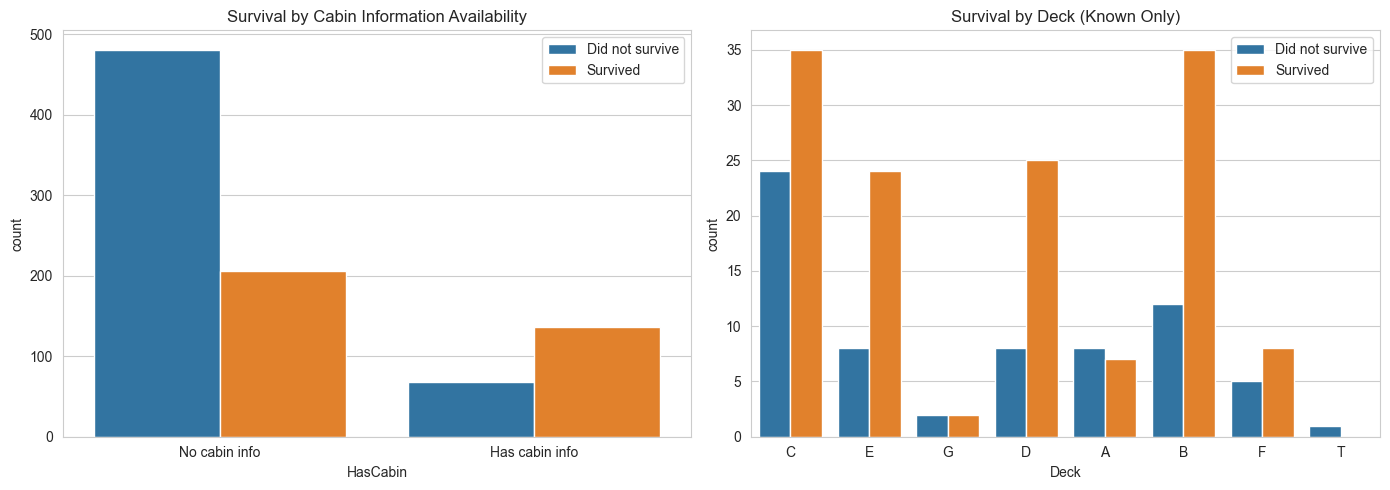


Survival Rate by HasCabin:
HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


In [27]:
# Create HasCabin feature (indicator if cabin information is available)
df_processed['HasCabin'] = df_processed['Cabin'].notna().astype(int)

# Extract deck (first letter of cabin)
df_processed['Deck'] = df_processed['Cabin'].str[0]

# Fill missing deck with 'Unknown'
df_processed['Deck'].fillna('Unknown', inplace=True)

print("Deck Distribution:")
print(df_processed['Deck'].value_counts())

# Visualize survival by HasCabin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_processed, x='HasCabin', hue='Survived', ax=axes[0])
axes[0].set_title('Survival by Cabin Information Availability')
axes[0].set_xticklabels(['No cabin info', 'Has cabin info'])
axes[0].legend(['Did not survive', 'Survived'])

# Survival rate by deck (excluding Unknown)
deck_data = df_processed[df_processed['Deck'] != 'Unknown']
if len(deck_data) > 0:
    sns.countplot(data=deck_data, x='Deck', hue='Survived', ax=axes[1])
    axes[1].set_title('Survival by Deck (Known Only)')
    axes[1].legend(['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()

print("\nSurvival Rate by HasCabin:")
print(df_processed.groupby('HasCabin')['Survived'].mean())

### 7.5 Create Age Groups (Now that Age is Complete)

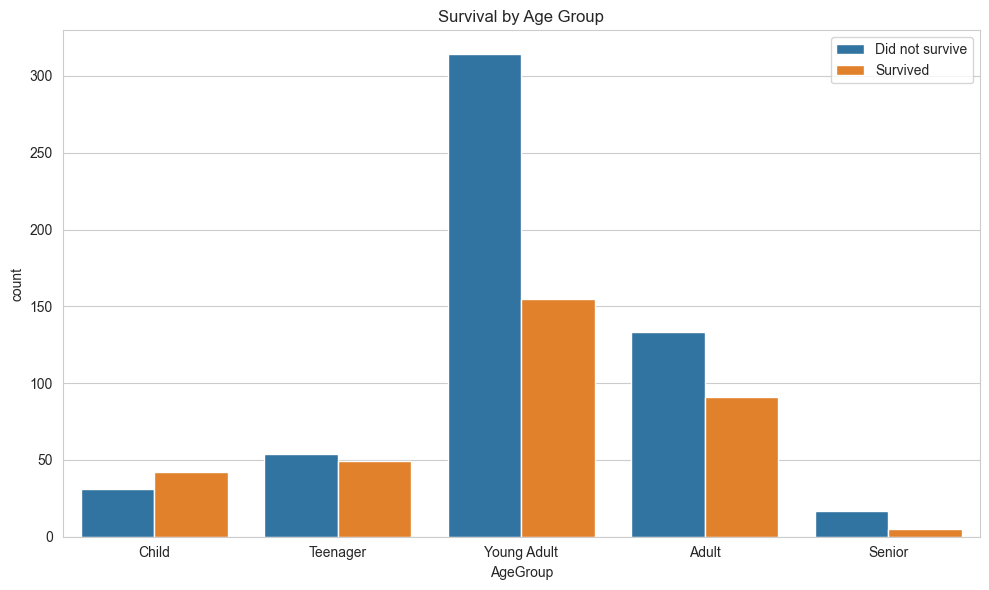

Survival Rate by Age Group:
AgeGroup
Child          0.575342
Teenager       0.475728
Young Adult    0.330490
Adult          0.406250
Senior         0.227273
Name: Survived, dtype: float64


In [28]:
# Create age groups
df_processed['AgeGroup'] = pd.cut(df_processed['Age'], 
                                  bins=[0, 12, 18, 35, 60, 100],
                                  labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'])

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df_processed, x='AgeGroup', hue='Survived', ax=ax)
ax.set_title('Survival by Age Group')
ax.legend(['Did not survive', 'Survived'])
plt.tight_layout()
plt.show()

print("Survival Rate by Age Group:")
print(df_processed.groupby('AgeGroup')['Survived'].mean())

### 7.6 Verify No Missing Values

In [29]:
# Check for remaining missing values
print("Remaining Missing Values:")
remaining_missing = df_processed.isnull().sum()
print(remaining_missing[remaining_missing > 0])

if remaining_missing.sum() == 0:
    print("\nAll missing values have been handled!")

Remaining Missing Values:
Cabin    687
dtype: int64


## 8. Encode Categorical Variables

In [30]:
# Create a copy for encoding
df_encoded = df_processed.copy()

In [31]:
# Binary encoding for Sex
df_encoded['Sex'] = df_encoded['Sex'].map({'male': 0, 'female': 1})

# One-hot encoding for Embarked
embarked_dummies = pd.get_dummies(df_encoded['Embarked'], prefix='Embarked', drop_first=True)
df_encoded = pd.concat([df_encoded, embarked_dummies], axis=1)

# One-hot encoding for Title
title_dummies = pd.get_dummies(df_encoded['Title'], prefix='Title', drop_first=True)
df_encoded = pd.concat([df_encoded, title_dummies], axis=1)

# One-hot encoding for AgeGroup
agegroup_dummies = pd.get_dummies(df_encoded['AgeGroup'], prefix='AgeGroup', drop_first=True)
df_encoded = pd.concat([df_encoded, agegroup_dummies], axis=1)

# One-hot encoding for Deck (optional - many unknown values)
deck_dummies = pd.get_dummies(df_encoded['Deck'], prefix='Deck', drop_first=True)
df_encoded = pd.concat([df_encoded, deck_dummies], axis=1)

print("Encoded dataset shape:", df_encoded.shape)
print("\nNew columns:")
print(df_encoded.columns.tolist())

Encoded dataset shape: (891, 37)

New columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'FarePerPerson', 'HasCabin', 'Deck', 'AgeGroup', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teenager', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


## 9. Select Features for Model Training

In [32]:
# Drop columns that won't be used for modeling
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked', 'Title', 'AgeGroup', 'Deck']
df_final = df_encoded.drop(columns=columns_to_drop)

print("Final dataset shape:", df_final.shape)
print("\nFinal columns:")
print(df_final.columns.tolist())

# Display first few rows
df_final.head()

Final dataset shape: (891, 29)

Final columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'HasCabin', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teenager', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,...,AgeGroup_Adult,AgeGroup_Senior,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,22.0,1,0,7.2500,2,0,3.62500,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,0,35.64165,...,1,0,0,1,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,1,1,7.92500,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,35.0,1,0,53.1000,2,0,26.55000,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,35.0,0,0,8.0500,1,1,8.05000,...,0,0,0,0,0,0,0,0,0,1


## 10. Data Summary

In [33]:
print("=" * 80)
print("DATA PREPROCESSING SUMMARY")
print("=" * 80)
print(f"\nOriginal dataset shape: {df.shape}")
print(f"Processed dataset shape: {df_final.shape}")
print(f"\nNumber of features: {df_final.shape[1] - 1}")
print(f"Target variable: Survived")
print(f"\nSurvival rate: {df_final['Survived'].mean():.2%}")
print(f"\nData types:")
print(df_final.dtypes.value_counts())
print(f"\nMissing values: {df_final.isnull().sum().sum()}")
print("\nFeatures created:")
print("  - FamilySize: SibSp + Parch + 1")
print("  - IsAlone: Binary indicator if traveling alone")
print("  - Title: Extracted from Name and grouped")
print("  - AgeGroup: Categorical age ranges")
print("  - HasCabin: Binary indicator of cabin information")
print("  - Deck: First letter of cabin")
print("  - FarePerPerson: Fare divided by family size")
print("\nEncoding applied:")
print("  - Sex: Binary encoding (male=0, female=1)")
print("  - Embarked, Title, AgeGroup, Deck: One-hot encoding")
print("=" * 80)

DATA PREPROCESSING SUMMARY

Original dataset shape: (891, 12)
Processed dataset shape: (891, 29)

Number of features: 28
Target variable: Survived

Survival rate: 38.38%

Data types:
uint8      18
int64       6
float64     3
int32       2
dtype: int64

Missing values: 0

Features created:
  - FamilySize: SibSp + Parch + 1
  - IsAlone: Binary indicator if traveling alone
  - Title: Extracted from Name and grouped
  - AgeGroup: Categorical age ranges
  - HasCabin: Binary indicator of cabin information
  - Deck: First letter of cabin
  - FarePerPerson: Fare divided by family size

Encoding applied:
  - Sex: Binary encoding (male=0, female=1)
  - Embarked, Title, AgeGroup, Deck: One-hot encoding


## 11. Save Processed Dataset

In [34]:
# Create processed data directory if it doesn't exist
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

# Save the processed dataset
output_path = processed_dir / 'titanic_processed.csv'
df_final.to_csv(output_path, index=False)

print(f"Processed dataset saved to: {output_path}")
print(f"Shape: {df_final.shape}")
print(f"\nProcessing complete!")

Processed dataset saved to: ..\data\processed\titanic_processed.csv
Shape: (891, 29)

Processing complete!
